# NLP Project 7: Hotel Review Analysis

This notebook analyzes hotel guest reviews using NLP to check sentiment and find service issues.

## 1. Import Libraries

In [9]:
import pandas as pd
import re
import matplotlib.pyplot as plt

## 2. Collect Hotel Review Data
Sample reviews are used here. You can replace this with a CSV file of real reviews using `pd.read_csv('reviews.csv')`.

In [10]:
data = {
    "review": [
        "The room was clean and the staff was very friendly and helpful.",
        "Food quality was bad and cold when it arrived.",
        "Amazing stay, loved the amenities and the pool area.",
        "Staff behavior was rude and unprofessional during checkin.",
        "Room was dirty and smelled bad, very disappointed.",
        "Great food service and quick room service response.",
        "The hotel amenities like gym and spa were excellent.",
        "Cleanliness of the room was very poor, found stains on bedsheet.",
        "Staff was polite and rooms were spacious and comfortable.",
        "Food was tasty but staff took too long to serve.",
        "Wonderful experience overall, will visit again.",
        "Worst hotel experience, room was not properly cleaned.",
        "Amenities were outdated and gym equipment was broken.",
        "Very cooperative staff, helped us with everything.",
        "Room service was slow and food was cold."
    ]
}

df = pd.DataFrame(data)
df.head()

,review
0,The room was clean and the staff was very frie...
1,Food quality was bad and cold when it arrived.
2,"Amazing stay, loved the amenities and the pool..."
3,Staff behavior was rude and unprofessional dur...
4,"Room was dirty and smelled bad, very disappoin..."


## 3. Preprocess Guest Reviews
Lowercase text, remove punctuation and remove stopwords.

In [11]:
stopwords = set("a an the is was were are be been being to of in on at for and or but with this that it its i we you he she they them his her their".split())

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    words = text.split()
    words = [w for w in words if w not in stopwords]
    return " ".join(words)

df["clean_review"] = df["review"].apply(clean_text)
df.head()

,review,clean_review
0,The room was clean and the staff was very frie...,room clean staff very friendly helpful
1,Food quality was bad and cold when it arrived.,food quality bad cold when arrived
2,"Amazing stay, loved the amenities and the pool...",amazing stay loved amenities pool area
3,Staff behavior was rude and unprofessional dur...,staff behavior rude unprofessional during checkin
4,"Room was dirty and smelled bad, very disappoin...",room dirty smelled bad very disappointed


## 4. Sentiment Analysis
A simple word list based approach is used to mark each review as Positive, Negative or Neutral.

In [12]:
positive_words = set("good great excellent amazing wonderful clean friendly helpful polite comfortable spacious tasty quick cooperative loved best nice happy satisfied".split())
negative_words = set("bad rude dirty poor slow cold disappointed worst outdated broken unprofessional stains delay noisy uncomfortable smelled".split())

def get_sentiment(text):
    words = text.split()
    pos = sum(1 for w in words if w in positive_words)
    neg = sum(1 for w in words if w in negative_words)
    if pos > neg:
        return "Positive"
    elif neg > pos:
        return "Negative"
    else:
        return "Neutral"

df["sentiment"] = df["clean_review"].apply(get_sentiment)
df[["review", "sentiment"]]

,review,sentiment
0,The room was clean and the staff was very frie...,Positive
1,Food quality was bad and cold when it arrived.,Negative
2,"Amazing stay, loved the amenities and the pool...",Positive
3,Staff behavior was rude and unprofessional dur...,Negative
4,"Room was dirty and smelled bad, very disappoin...",Negative
5,Great food service and quick room service resp...,Positive
6,The hotel amenities like gym and spa were exce...,Positive
7,"Cleanliness of the room was very poor, found s...",Negative
8,Staff was polite and rooms were spacious and c...,Positive
9,Food was tasty but staff took too long to serve.,Positive


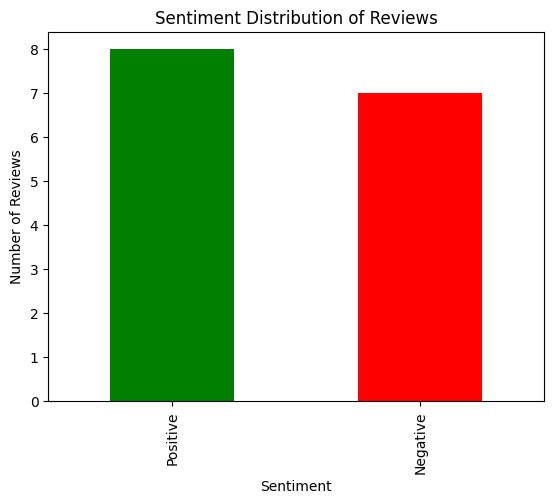

In [13]:
sentiment_counts = df["sentiment"].value_counts()
sentiment_counts.plot(kind="bar", color=["green", "red", "grey"])
plt.title("Sentiment Distribution of Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

## 5. Identify Service-Related Issues
Check negative reviews for keywords related to room, staff, food, cleanliness and amenities.

In [14]:
categories = {
    "Room Quality": ["room", "bed", "spacious"],
    "Staff Behavior": ["staff", "service", "checkin", "cooperative"],
    "Cleanliness": ["clean", "dirty", "stains", "smelled"],
    "Food Service": ["food", "meal", "tasty"],
    "Amenities": ["amenities", "gym", "spa", "pool"]
}

def find_category(text):
    found = []
    for cat, keywords in categories.items():
        for word in keywords:
            if word in text:
                found.append(cat)
                break
    return found

negative_df = df[df["sentiment"] == "Negative"].copy()
negative_df["issue_category"] = negative_df["clean_review"].apply(find_category)
negative_df[["review", "issue_category"]]

,review,issue_category
1,Food quality was bad and cold when it arrived.,[Food Service]
3,Staff behavior was rude and unprofessional dur...,[Staff Behavior]
4,"Room was dirty and smelled bad, very disappoin...","[Room Quality, Cleanliness]"
7,"Cleanliness of the room was very poor, found s...","[Room Quality, Cleanliness]"
11,"Worst hotel experience, room was not properly ...","[Room Quality, Cleanliness]"
12,Amenities were outdated and gym equipment was ...,[Amenities]
14,Room service was slow and food was cold.,"[Room Quality, Staff Behavior, Food Service]"


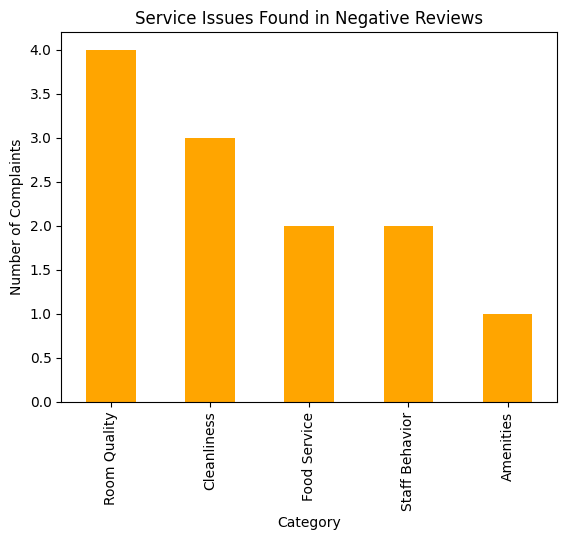

In [15]:
issue_counts = {}
for cats in negative_df["issue_category"]:
    for cat in cats:
        issue_counts[cat] = issue_counts.get(cat, 0) + 1

issue_series = pd.Series(issue_counts).sort_values(ascending=False)
issue_series.plot(kind="bar", color="orange")
plt.title("Service Issues Found in Negative Reviews")
plt.xlabel("Category")
plt.ylabel("Number of Complaints")
plt.show()

## 6. Generate Customer Satisfaction Report

In [16]:
total_reviews = len(df)
positive_pct = round((df["sentiment"] == "Positive").sum() / total_reviews * 100, 2)
negative_pct = round((df["sentiment"] == "Negative").sum() / total_reviews * 100, 2)
neutral_pct = round((df["sentiment"] == "Neutral").sum() / total_reviews * 100, 2)

print("Customer Satisfaction Report")
print("-----------------------------")
print(f"Total Reviews Analyzed: {total_reviews}")
print(f"Positive Reviews: {positive_pct}%")
print(f"Negative Reviews: {negative_pct}%")
print(f"Neutral Reviews: {neutral_pct}%")
print()
print("Top Areas Needing Improvement:")
print(issue_series)

Customer Satisfaction Report
-----------------------------
Total Reviews Analyzed: 15
Positive Reviews: 53.33%
Negative Reviews: 46.67%
Neutral Reviews: 0.0%

Top Areas Needing Improvement:
Room Quality      4
Cleanliness       3
Food Service      2
Staff Behavior    2
Amenities         1
dtype: int64


## Conclusion
Most guests are satisfied overall, but the report highlights specific areas like cleanliness, staff behavior and food service that need improvement. This can help the hotel management team take action to improve guest experience.